# Entrega 6 — Componente Avanzado: PCA + t-SNE
**Proyecto SKI (Smart Kitchen Inventory)** · Curso: Data Visualization

## 1. Objetivo
Aplicar técnicas de reducción de dimensionalidad sobre la matriz de características de los movimientos de inventario (25,819 eventos) para:
1. Identificar la **estructura latente** del comportamiento de consumo/compra de los hogares.
2. Cuantificar cuántas dimensiones reales contiene la información (varianza retenida).
3. Generar coordenadas 2D exportables a **Tableau** para la vista avanzada del dashboard beta.

## 2. Metodología
- **Fuente:** `data/processed/inventory_v1.csv` (dataset limpio validado en Entrega 2).
- **Features (`src/features.py`):** 61 variables = 3 numéricas nutricionales (imputación por media de categoría) + one-hot de categoría + TF-IDF del nombre de producto (50 términos) + 2 temporales (hora, día de semana). Escalado con `StandardScaler`.
- **PCA:** lineal, sobre la matriz completa. Criterio: umbral de 90% de varianza acumulada.
- **t-SNE:** no lineal, captura estructura local. Parámetros: `perplexity=30`, `init='pca'`, `learning_rate='auto'`, `random_state=42`. Se aplica sobre una **muestra aleatoria reproducible de 5,000 registros** con pre-reducción PCA a 30 dims (práctica recomendada para denoising y costo computacional, ya que t-SNE es O(n²)).

In [ ]:
import subprocess
import sys
from pathlib import Path

# Este notebook consume data/features/feature_matrix.npy y outputs/*_tableau.csv,
# outputs/reduction_summary.json, generados por src/features.py y src/reduction.py.
# Ningun notebook de la cadena 00-05 los produce, asi que sin este bloque el
# notebook solo "funciona" si alguien corrio esos scripts a mano antes (como
# paso oculto, no reproducible). Aqui se generan automaticamente si faltan.
REPO_ROOT = Path.cwd().parent
REQUIRED = [
    REPO_ROOT / 'data' / 'features' / 'feature_matrix.npy',
    REPO_ROOT / 'data' / 'features' / 'feature_names.json',
    REPO_ROOT / 'outputs' / 'tsne_sample_tableau.csv',
    REPO_ROOT / 'outputs' / 'pca_components_tableau.csv',
    REPO_ROOT / 'outputs' / 'pca_variance_table.csv',
    REPO_ROOT / 'outputs' / 'reduction_summary.json',
]
faltantes = [p for p in REQUIRED if not p.exists()]

if faltantes:
    print(f'Faltan {len(faltantes)} artefactos, generando con src/features.py y src/reduction.py...')
    for script in ['src/features.py', 'src/reduction.py']:
        result = subprocess.run([sys.executable, script], capture_output=True, text=True,
                                 cwd=str(REPO_ROOT), timeout=600)
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            raise RuntimeError(f'{script} fallo con codigo {result.returncode}')
else:
    print('Todos los artefactos de features/reduccion ya existen — no hace falta regenerarlos.')

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from IPython.display import Image, display

X = np.load('../data/features/feature_matrix.npy')
feature_names = json.load(open('../data/features/feature_names.json'))
print(f'Matriz de features: {X.shape[0]} registros x {X.shape[1]} variables')
print('Ejemplos de variables:', feature_names[:5], '...')

Matriz de features: 25819 registros x 61 variables
Ejemplos de variables: ['calories_100g', 'proteins_100g', 'carbs_100g', 'category_name_Bebidas', 'category_name_Congelados'] ...


## 3. PCA: varianza explicada (energía retenida)

In [2]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(X)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = int(np.argmax(cumvar >= 0.90) + 1)

tabla = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(10)],
    'Varianza explicada (%)': (pca.explained_variance_ratio_[:10]*100).round(2),
    'Varianza acumulada (%)': (cumvar[:10]*100).round(2),
})
print(f'Dimensión original: {X.shape[1]} | Componentes para retener 90%: {n_90}')
tabla

Dimensión original: 61 | Componentes para retener 90%: 29


,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,8.03,8.03
1,PC2,6.76,14.79
2,PC3,5.59,20.38
3,PC4,5.07,25.45
4,PC5,4.79,30.25
5,PC6,3.84,34.08
6,PC7,3.79,37.87
7,PC8,3.70,41.58
8,PC9,3.67,45.24
9,PC10,3.53,48.77


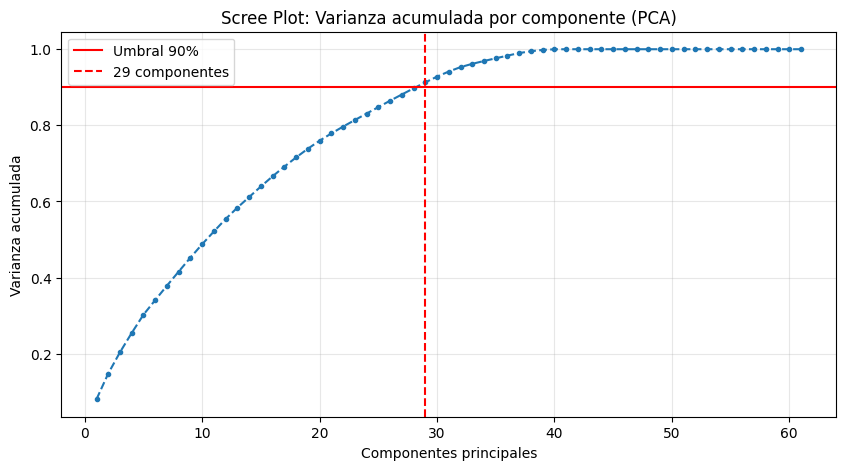

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3, linestyle='--')
plt.axhline(0.90, color='r', label='Umbral 90%')
plt.axvline(n_90, color='r', linestyle='--', label=f'{n_90} componentes')
plt.title('Scree Plot: Varianza acumulada por componente (PCA)')
plt.xlabel('Componentes principales'); plt.ylabel('Varianza acumulada')
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Interpretación:** la varianza está distribuida entre muchas variables (TF-IDF dispersa), por lo que ningún componente domina. Aun así, ~29 de 61 componentes retienen el 90% de la información: la dimensionalidad efectiva es la mitad de la original.

## 4. Proyección PCA 2D

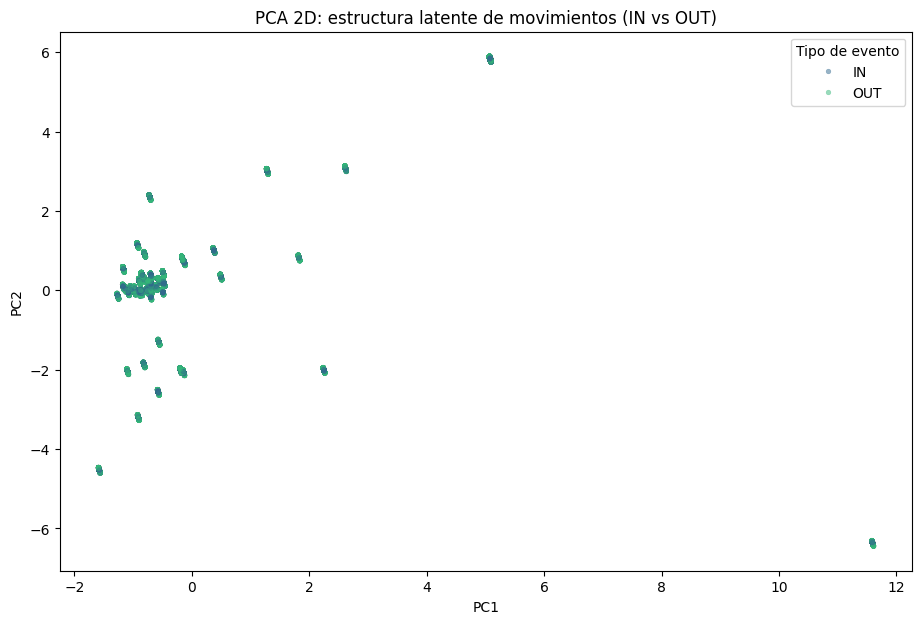

In [4]:
import seaborn as sns

df_meta = pd.read_csv('../data/processed/inventory_v1.csv')
X3 = PCA(n_components=3, random_state=42).fit_transform(X)

plt.figure(figsize=(11, 7))
sns.scatterplot(x=X3[:,0], y=X3[:,1], hue=df_meta['action_type'], palette='viridis', alpha=0.5, s=12, edgecolor=None)
plt.title('PCA 2D: estructura latente de movimientos (IN vs OUT)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(title='Tipo de evento'); plt.show()

## 5. t-SNE 2D (cargado del pipeline `src/reduction.py`)

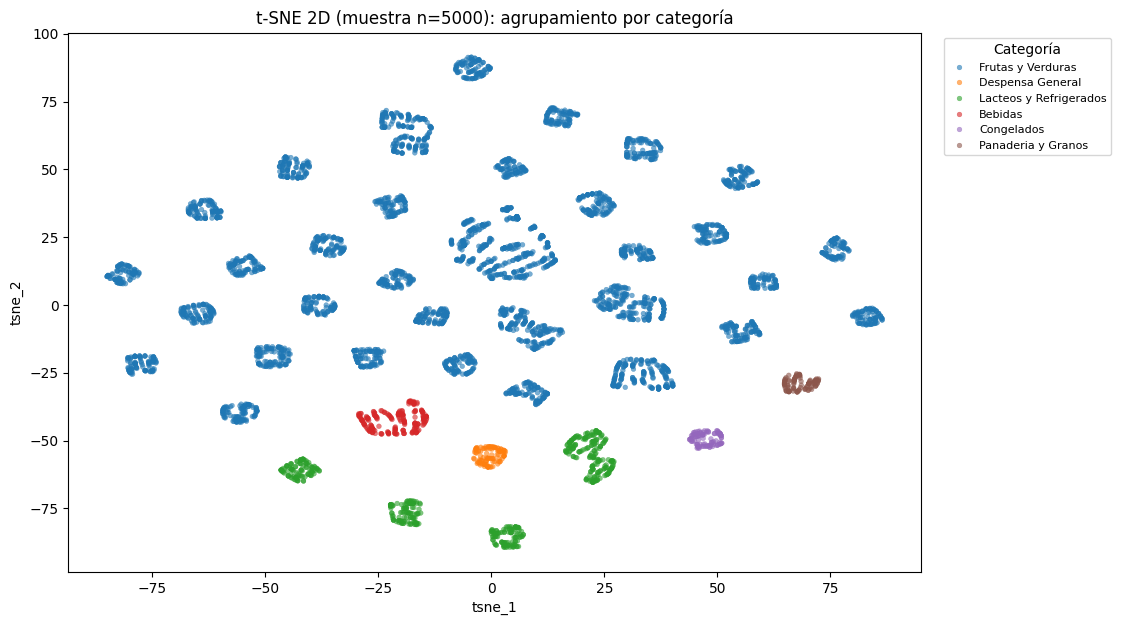

{'dim_original': 61,
 'n_registros': 25819,
 'componentes_para_90pct': 29,
 'pca_var_pc1': 0.08031810583558141,
 'pca_var_pc2': 0.06758571443450284,
 'pca_var_pc3': 0.05588636508810924,
 'tsne_sample_size': 5000,
 'tsne_perplexity': 30,
 'tsne_pre_pca_dims': 30,
 'random_state': 42}

In [5]:
df_tsne = pd.read_csv('../outputs/tsne_sample_tableau.csv')
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='category_name', palette='tab10', alpha=0.6, s=12, edgecolor=None)
plt.title(f't-SNE 2D (muestra n={len(df_tsne)}): agrupamiento por categoría')
plt.legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()
summary = json.load(open('../outputs/reduction_summary.json'))
summary

**Interpretación:** t-SNE separa clusters compactos que corresponden mayoritariamente a **categorías de producto** (impulsadas por el TF-IDF del nombre y el perfil nutricional), con subestructura interna asociada a patrones horarios. PCA conserva la geometría global; t-SNE revela los grupos locales — por eso se reportan ambos.

## 6. Exportables para Tableau (vista avanzada del dashboard beta)

| Archivo | Contenido | Uso en Tableau |
|---|---|---|
| `outputs/pca_components_tableau.csv` | 25,819 filas, PC1–PC3 + metadata | Scatter PC1 vs PC2, color por `action_type`/`category_name`, filtros por hogar |
| `outputs/tsne_sample_tableau.csv` | 5,000 filas, tsne_1/tsne_2 + metadata | Scatter t-SNE, color por categoría, tooltip con producto |
| `outputs/pca_variance_table.csv` | varianza por componente | Gráfico de barras/Pareto de energía retenida |

## 7. Limitaciones
- t-SNE se calculó sobre una muestra (5,000 de 25,819) por costo O(n²); las distancias globales entre clusters de t-SNE **no son interpretables**, solo la pertenencia a grupos.
- El dataset proviene de una **simulación calibrada** con patrones reales de Instacart + nutrición USDA; los clusters reflejan la estructura simulada.
- PCA es lineal: con 61 variables dispersas (TF-IDF) la varianza por componente es baja; el scree plot debe leerse de forma acumulada.
- `random_state=42` fijo garantiza reproducibilidad de muestra y proyecciones.